In [1]:
import pandas as pd
from ggner_3d.boundaries import assign_domain_score, multi_upper_threshold, make_tads
from ggner_3d.cm import get_expected_cis_df, prepare_view_df, CLR_CONNS, get_eig_data
from ggner_3d import plotting
plotting.update_rcparams()

import bioframe as bf
import ptitprince as pt
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import ptitprince as pt
from statannotations.Annotator import Annotator
import numpy as np
import seaborn as sns
from coolpuppy import coolpup

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

window_bp = 500_000
bin_bp = 10_000

# tad lengths
MAXLEN = 2e6
MINLEN = 2.5e5

rescale_flank = 1
rescale_size = 33 * (2 * rescale_flank + 1)
assert rescale_size % (2 * rescale_flank + 1) == 0 and rescale_size % 2 == 1, "rescale_size"
score_flank=rescale_flank

clr_ = CLR_CONNS(bin_bp)

In [3]:
insulation_path = '/home/carlos/Clone/ggner-3d/data/insulation'

columns_oi = ['chrom', 'start', 'end', 'region', 'is_bad_bin', f'log2_insulation_score_{window_bp}', f'n_valid_pixels_{window_bp}', f'boundary_strength_{window_bp}', f'is_boundary_{window_bp}']
insulation_dfs = {k: pd.read_csv(f'{insulation_path}/insulation_{k}_{bin_bp}bp.csv')[columns_oi] for k in clr_.keys()}

In [4]:
def sample_name_formatter(x: str) -> str:
    # return x.replace('WT', 'WT ').replace('XPA', 'XPA ').replace('XPC', 'XPC ')
    return x.replace('WT', 'WT').replace('XPA', 'XPA').replace('XPC', 'XPC')


In [5]:
samples_oi = ['WTnoUV', 'WT1h', 'WT3h', 'WT6h', 'XPCnoUV', 'XPC3h', 'XPAnoUV', 'XPA1h', 'XPA3h', 'XPA6h']

### bs - ptitprince

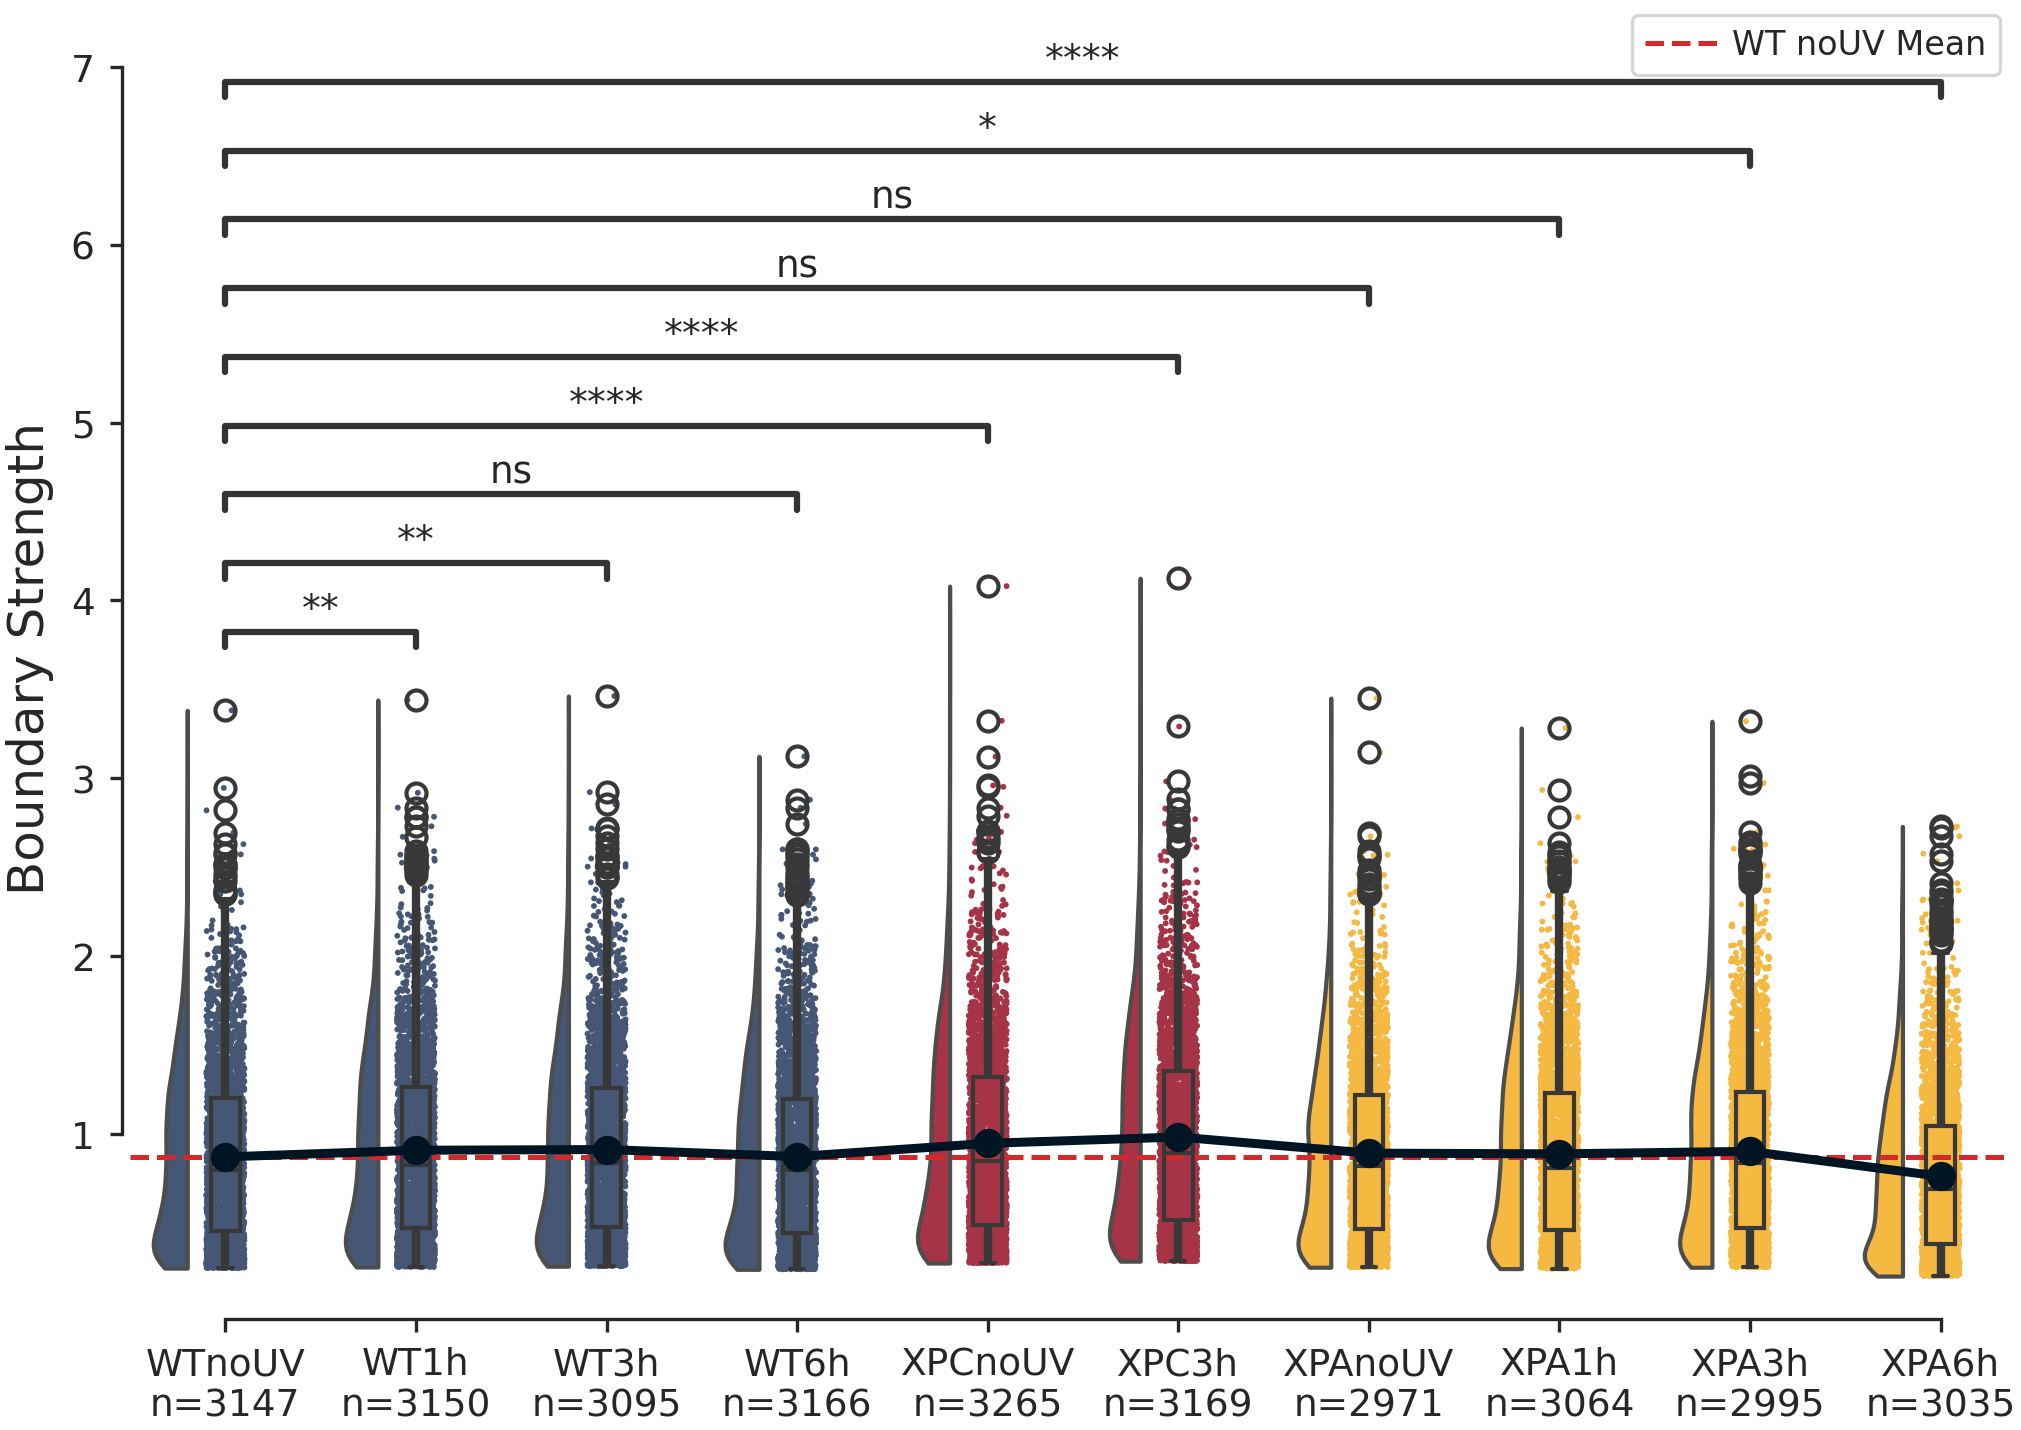

In [6]:
plot_df = {
    'sample': [],
    'bs': []
}

filter_by_independent_thr = True

if filter_by_independent_thr:
    for sample in samples_oi:
        current_df = insulation_dfs[sample]
        bs_scores = current_df.loc[
            current_df[f'is_boundary_{window_bp}'] == True,
            f'boundary_strength_{window_bp}'
        ].to_numpy()

        plot_df['sample'].extend([sample_name_formatter(sample)] * len(bs_scores))
        plot_df['bs'].extend(bs_scores.tolist())
else:
    l = []
    for sample in samples_oi:
        current_df = insulation_dfs[sample]
        l.append(current_df.loc[current_df[f'boundary_strength_{window_bp}'].notna(), f'boundary_strength_{window_bp}'].to_numpy())
    thr = multi_upper_threshold(l, method='otsu')
    for sample in samples_oi:
        current_df = insulation_dfs[sample]
        bs_scores = current_df.loc[
            current_df[f'boundary_strength_{window_bp}'] >= thr,
            f'boundary_strength_{window_bp}'
        ].to_numpy()

        plot_df['sample'].extend([sample_name_formatter(sample)] * len(bs_scores))
        plot_df['bs'].extend(bs_scores.tolist())

plot_df = pd.DataFrame(plot_df)

# -----------------------
# plot config
# -----------------------
ort = 'v'
# pal = plotting.COLORS
pal = [plotting.COLORS[0]] * 4 + [plotting.COLORS[1]] * 2 + [plotting.COLORS[2]] * 4
dx = 'sample'
dy = 'bs'
sigma = 0.2

# IMPORTANT: define a stable category order for both RainCloud + statannotations
order = [sample_name_formatter(s) for s in samples_oi]  # -> ['WT noUV','WT 1h','WT 3h','WT 6h']

# -----------------------
# raincloud plot
# -----------------------
fig, ax = plt.subplots(figsize=(7, 5))

# NOTE: Don't set hue="sample" when x="sample" (redundant and can confuse annotation pairing).
ax = pt.RainCloud(
    x=dx,
    y=dy,
    data=plot_df,
    order=order,
    palette=pal,
    bw=sigma,
    width_viol=0.4,
    ax=ax,
    orient=ort,
    move=0.0,
    pointplot=True,
    point_size=1.4,
    linecolor="#001524",
)

ax.set_ylabel('Boundary Strength')
# add n boundaries to x tick labels
xticks = []
for sample in order:
    n_boundaries = plot_df.loc[plot_df['sample'] == sample, 'bs'].shape[0]
    xticks.append(f'{sample}\nn={n_boundaries}')
ax.set_xticklabels(xticks)
ax.set_xlabel('')

# WT mean line
wt_label = sample_name_formatter('WTnoUV')  # "WT noUV"
wt_mean = plot_df.loc[plot_df['sample'] == wt_label, 'bs'].mean()
ax.axhline(wt_mean, color='#d62828', linestyle='--', label='WT noUV Mean')

# -----------------------
# statannotations: compare each group vs WT noUV
# -----------------------
pairs = [(order[0], g) for g in order[1:]]  # WT noUV vs each other sample

annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x=dx,
    y=dy,
    order=order,
)

annot.configure(
    test="Mann-Whitney",              # alternatives: "t-test_ind", "Wilcoxon", ...
    text_format="star",               # alternatives: "simple" (shows p=...)
    loc="inside",                    # keeps brackets above the plot
    verbose=0
)

annot.apply_and_annotate()

ax.legend()
plotting.despine(ax)
plt.tight_layout()

# -----------------------
# save
# -----------------------
fig.savefig('/home/carlos/Clone/ggner-3d/figs/fig1/boundary_strengths_insulation_500kb_wtnouv_vs_all.svg')

### tad strength - wt no uv tads

In [ ]:
tads_df = insulation_dfs['WTnoUV'].loc[
    insulation_dfs['WTnoUV'][f'is_boundary_{window_bp}'] == True,
    ['chrom', 'start', 'end']
]
tads_df = make_tads(
    tads_df,
    maxlen = MAXLEN,
    minlen = MINLEN)
print(tads_df.shape)

(3095, 3)


In [8]:
wt_pup = {}
view_df = prepare_view_df(arm=True)
for s in ['WTnoUV', 'WT1h', 'WT3h', 'WT6h']:
    expected = get_expected_cis_df(s, label='arm', resolution_kb=bin_bp // 1000)
    clr = clr_[s]

    cc = coolpup.CoordCreator(tads_df, resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup = coolpup.PileUpper(clr, cc, expected=expected, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    wt_pup[s] = pup

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4_p', 'chr4_p'): 48
INFO:coolpuppy:('chr5_p', 'chr5_p'): 39
INFO:coolpuppy:('chr6_p', 'chr6_p'): 69
INFO:coolpuppy:('chr3_p', 'chr3_p'): 99
INFO:coolpuppy:('chr2_p', 'chr2_p'): 91
INFO:coolpuppy:('chr1_p', 'chr1_p'): 142
INFO:coolpuppy:('chr6_q', 'chr6_q'): 123
INFO:coolpuppy:('chr5_q', 'chr5_q'): 147
INFO:coolpuppy:('chr4_q', 'chr4_q'): 151
INFO:coolpuppy:('chr3_q', 'chr3_q'): 116
INFO:coolpuppy:('chr1_q', 'chr1_q'): 124
INFO:coolpuppy:('chr8_p', 'chr8_p'): 49
INFO:coolpuppy:('chr9_p', 'chr9_p'): 41
INFO:coolpuppy:('chr10_p', 'chr10_p'): 34
INFO:coolpuppy:('chr7_p', 'chr7_p'): 66
INFO:coolpuppy:('chr2_q', 'chr2_q'): 153
INFO:coolpuppy:('chr11_p', 'chr11_p'): 55
INFO:coolpuppy:('chr12_p', 'chr12_p'): 47
INFO:coolpuppy:('chr9_q', 'chr9_q'): 85
INFO:coolpuppy:('chr10_q', 'chr10_q'): 100
INFO:coolpuppy:('chr7_q', 'chr7_q'): 90
INFO:coolpuppy:('chr11_q', 'chr11_q'): 106
INFO:coolpuppy:('chr8_q', 'chr8_q'): 

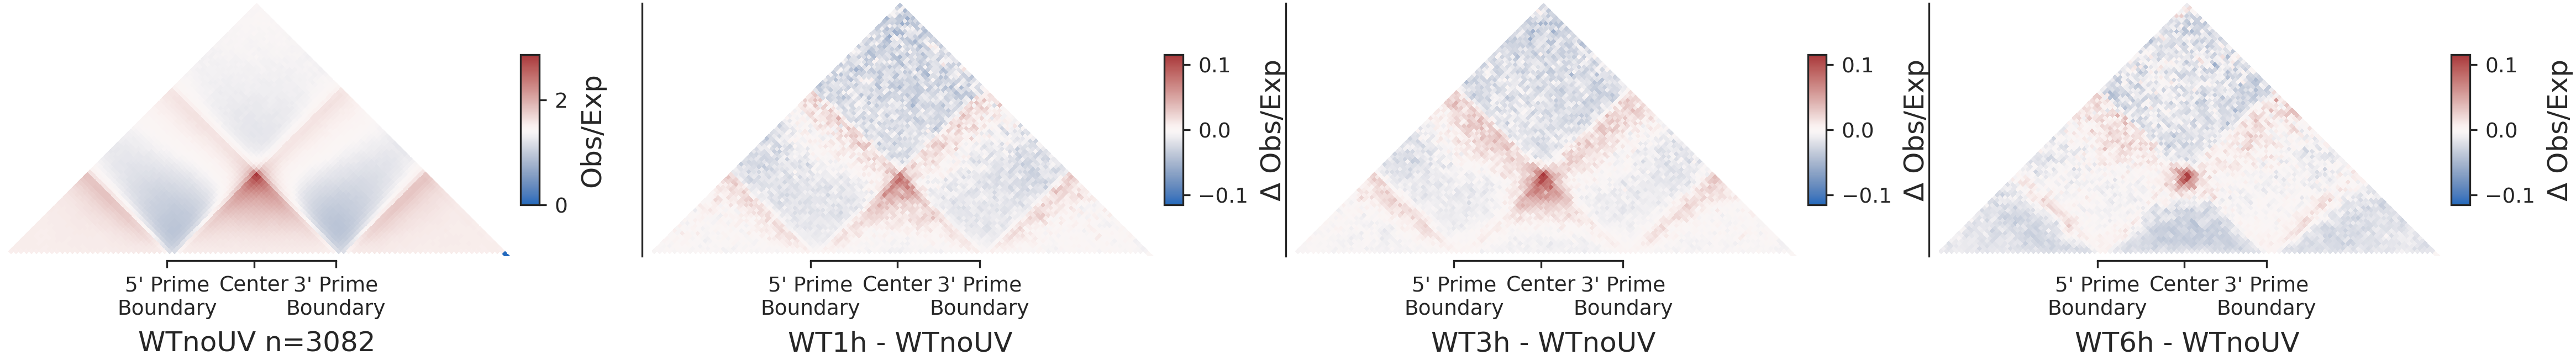

In [9]:
comps = [(0,1), (0,2), (0,3)]  # WTnoUV vs WT1h, WT3h, WT6h
all_diffs = []
for comp in comps:
    s1 = list(wt_pup.keys())[comp[0]]
    s2 = list(wt_pup.keys())[comp[1]]
    diff_mtx = wt_pup[s2]['data'][0] - wt_pup[s1]['data'][0]
    all_diffs.append(diff_mtx)
vmin, vmax = -np.nanmax(np.abs(all_diffs)), np.nanmax(np.abs(all_diffs))

aspect_ratio = 4.8
fig, axs = plt.subplots(1, 4, figsize=(4*aspect_ratio, 1*aspect_ratio))
plotting.update_rcparams()

ax = plotting.hic_upper_triangle(
    wt_pup['WTnoUV']['data'][0],
    cmap="vlag",
    center=1,
    ax=axs[0],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)

n = wt_pup['WTnoUV']['data'][0].shape[0]
n_bins_rescaled = 99
fiveprime_bin = int(n_bins_rescaled * 0.33)
threeprime_bin = int(n_bins_rescaled * 0.66)
center_bin = int(n_bins_rescaled * 0.5)
bins = np.array([fiveprime_bin, center_bin, threeprime_bin])

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticklabels(["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"])
ax.set_xlabel(f"WTnoUV n={wt_pup['WTnoUV'].n[0]}", labelpad=5)
# remove y ticks
ax.set_yticks([])
cbar = ax.figure.axes[-1]   # last axis is the colorbar
cbar.set_ylabel("Obs/Exp", labelpad=5)

plotting.despine(ax)

for i, comp in enumerate(comps):
    i1, i2 = comp
    s1, s2 = list(wt_pup.keys())[i1], list(wt_pup.keys())[i2]
    diff_mtx_comp = all_diffs[i]
    ax = plotting.hic_upper_triangle(
    diff_mtx_comp,
    cmap="vlag",
    center=0,
    vmin=vmin, vmax=vmax,
    ax=axs[i+1],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)


    n = diff_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticklabels(["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"])
    ax.set_xlabel(f"{s2} - {s1}", labelpad=5)
    # remove y ticks
    ax.set_yticks([])
    # drop y axis
    ax.get_yaxis().set_visible(False)
    cbar = ax.figure.axes[-1]   # last axis is the colorbar
    cbar.set_ylabel("Δ Obs/Exp", labelpad=5)
    plotting.despine(ax)

fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig1/tad_pileups_wtnouv_tads_and_deltas.svg'
)

### tad strength - preserved boundaries

In [10]:
from ggner_3d.boundaries import preserved_boundaries_only

comparisons = [(0, 1), (0, 2), (0, 3)]  # WTnoUV vs WT1h/3h/6h
sample_names_str = list(clr_.keys())[:4]  # ['WTnoUV', 'WT1h', 'WT3h', 'WT6h']

# nice labels for printing (optional)
comparisons_str = [f"{sample_names_str[i]} vs {sample_names_str[j]}" for i, j in comparisons]

insulation_dfs_now = [
    insulation_dfs[sample] for sample in sample_names_str
]

results, dfs = preserved_boundaries_only(
    insulation_table_=insulation_dfs_now,
    comparisons=comparisons,
    sample_names_str=sample_names_str,
    comparisons_str=comparisons_str,
    window=window_bp,
    accepted_range=1,
    verbose=True,
)

bins_table = clr_['WTnoUV'].bins()[:]
def bin_to_coords(df, bins_table, which_idx='idx1'):
    df = df.copy()
    bins_df = pd.DataFrame(bins_table, columns=['chrom', 'start', 'end'])
    bins_df['bin_id'] = bins_df.index
    df = df.merge(bins_df, left_on=which_idx, right_on='bin_id', how='left')
    return df

dfs = [bin_to_coords(df, bins_table) for df in dfs]

WTnoUV vs WT1h: Preserved / Increase ::: 1811
WTnoUV vs WT1h: Preserved / Decrease ::: 839
WTnoUV vs WT3h: Preserved / Increase ::: 1560
WTnoUV vs WT3h: Preserved / Decrease ::: 1002
WTnoUV vs WT6h: Preserved / Increase ::: 1159
WTnoUV vs WT6h: Preserved / Decrease ::: 1272


In [11]:
preserved_tads = [
    make_tads(df[['chrom', 'start', 'end']], maxlen=MAXLEN, minlen=MINLEN) for df in dfs
]

In [12]:
[len(df) for df in preserved_tads]

[2373, 2285, 2124]

In [13]:
wt_nouv_pup = []
wt_uv_pup = []
view_df = prepare_view_df(arm=True)
for i, s in enumerate(['WT1h', 'WT3h', 'WT6h']):
    expected_uv = get_expected_cis_df(s, label='arm', resolution_kb=bin_bp // 1000)
    clr_uv = clr_[s]

    expected_nouv = get_expected_cis_df('WTnoUV', label='arm', resolution_kb=bin_bp // 1000)
    clr_nouv = clr_['WTnoUV']

    cc = coolpup.CoordCreator(preserved_tads[i], resolution=10000, features_format='bed', local=True, rescale_flank=rescale_flank)
    pup_uv = coolpup.PileUpper(clr_uv, cc, expected=expected_uv, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    wt_uv_pup.append(pup_uv)

    pup_nouv = coolpup.PileUpper(clr_nouv, cc, expected=expected_nouv, view_df=view_df, ignore_diags=0, rescale_size=rescale_size, rescale=True, nproc=6).pileupsWithControl()
    wt_nouv_pup.append(pup_nouv)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr4_p', 'chr4_p'): 38
INFO:coolpuppy:('chr5_p', 'chr5_p'): 27
INFO:coolpuppy:('chr6_p', 'chr6_p'): 50
INFO:coolpuppy:('chr2_p', 'chr2_p'): 62
INFO:coolpuppy:('chr3_p', 'chr3_p'): 78
INFO:coolpuppy:('chr1_p', 'chr1_p'): 105
INFO:coolpuppy:('chr5_q', 'chr5_q'): 116
INFO:coolpuppy:('chr6_q', 'chr6_q'): 97
INFO:coolpuppy:('chr4_q', 'chr4_q'): 112
INFO:coolpuppy:('chr3_q', 'chr3_q'): 92
INFO:coolpuppy:('chr8_p', 'chr8_p'): 34
INFO:coolpuppy:('chr1_q', 'chr1_q'): 99
INFO:coolpuppy:('chr9_p', 'chr9_p'): 29
INFO:coolpuppy:('chr7_p', 'chr7_p'): 59
INFO:coolpuppy:('chr10_p', 'chr10_p'): 30
INFO:coolpuppy:('chr2_q', 'chr2_q'): 125
INFO:coolpuppy:('chr11_p', 'chr11_p'): 40
INFO:coolpuppy:('chr12_p', 'chr12_p'): 35
INFO:coolpuppy:('chr9_q', 'chr9_q'): 73
INFO:coolpuppy:('chr8_q', 'chr8_q'): 81
INFO:coolpuppy:('chr7_q', 'chr7_q'): 69
INFO:coolpuppy:('chr10_q', 'chr10_q'): 70
INFO:coolpuppy:('chr11_q', 'chr11_q'): 87
IN

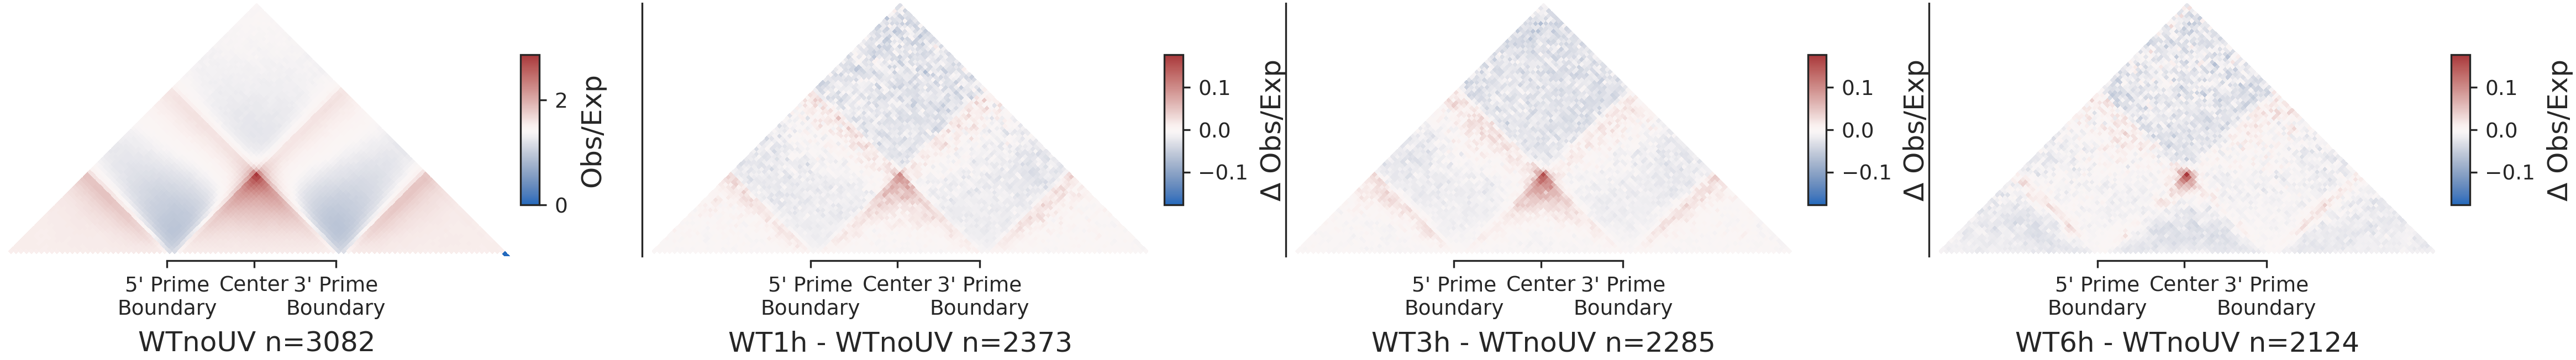

In [14]:
all_diffs = []
for i in range(3):
    diff_mtx = wt_uv_pup[i]['data'][0] - wt_nouv_pup[i]['data'][0]
    all_diffs.append(diff_mtx)
vmin, vmax = -np.nanmax(np.abs(all_diffs)), np.nanmax(np.abs(all_diffs))

aspect_ratio = 4.8
fig, axs = plt.subplots(1, 4, figsize=(4*aspect_ratio, 1*aspect_ratio))
plotting.update_rcparams()

ax = plotting.hic_upper_triangle(
    wt_pup['WTnoUV']['data'][0],
    cmap="vlag",
    center=1,
    ax=axs[0],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)

n = wt_pup['WTnoUV']['data'][0].shape[0]
n_bins_rescaled = 99
fiveprime_bin = int(n_bins_rescaled * 0.33)
threeprime_bin = int(n_bins_rescaled * 0.66)
center_bin = int(n_bins_rescaled * 0.5)
bins = np.array([fiveprime_bin, center_bin, threeprime_bin])

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticklabels(["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"])
ax.set_xlabel(f"WTnoUV n={wt_pup['WTnoUV'].n[0]}", labelpad=5)
# remove y ticks
ax.set_yticks([])
cbar = ax.figure.axes[-1]   # last axis is the colorbar
cbar.set_ylabel("Obs/Exp", labelpad=5)

plotting.despine(ax)


tads_lens = [len(tads) for tads in preserved_tads]
for i, comp in enumerate(comps):
    i1, i2 = comp
    s1, s2 = list(wt_pup.keys())[i1], list(wt_pup.keys())[i2]
    diff_mtx_comp = all_diffs[i]
    ax = plotting.hic_upper_triangle(
    diff_mtx_comp,
    cmap="vlag",
    center=0,
    vmin=vmin, vmax=vmax,
    ax=axs[i+1],
    colorbar=True,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)


    n = diff_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticklabels(["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"])
    ax.set_xlabel(f"{s2} - {s1} n={tads_lens[i]}", labelpad=5)
    # remove y ticks
    ax.set_yticks([])
    # drop y axis
    ax.get_yaxis().set_visible(False)
    cbar = ax.figure.axes[-1]   # last axis is the colorbar
    cbar.set_ylabel("Δ Obs/Exp", labelpad=5)
    plotting.despine(ax)

fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig1/tad_pileups_wtnouv_tads_and_deltas_preserved.svg'
)

/tmp/ipykernel_261481/1690728810.py:21: RuntimeWarning: divide by zero encountered in log2
  np.log2(wt_pup['WTnoUV']['data'][0]),


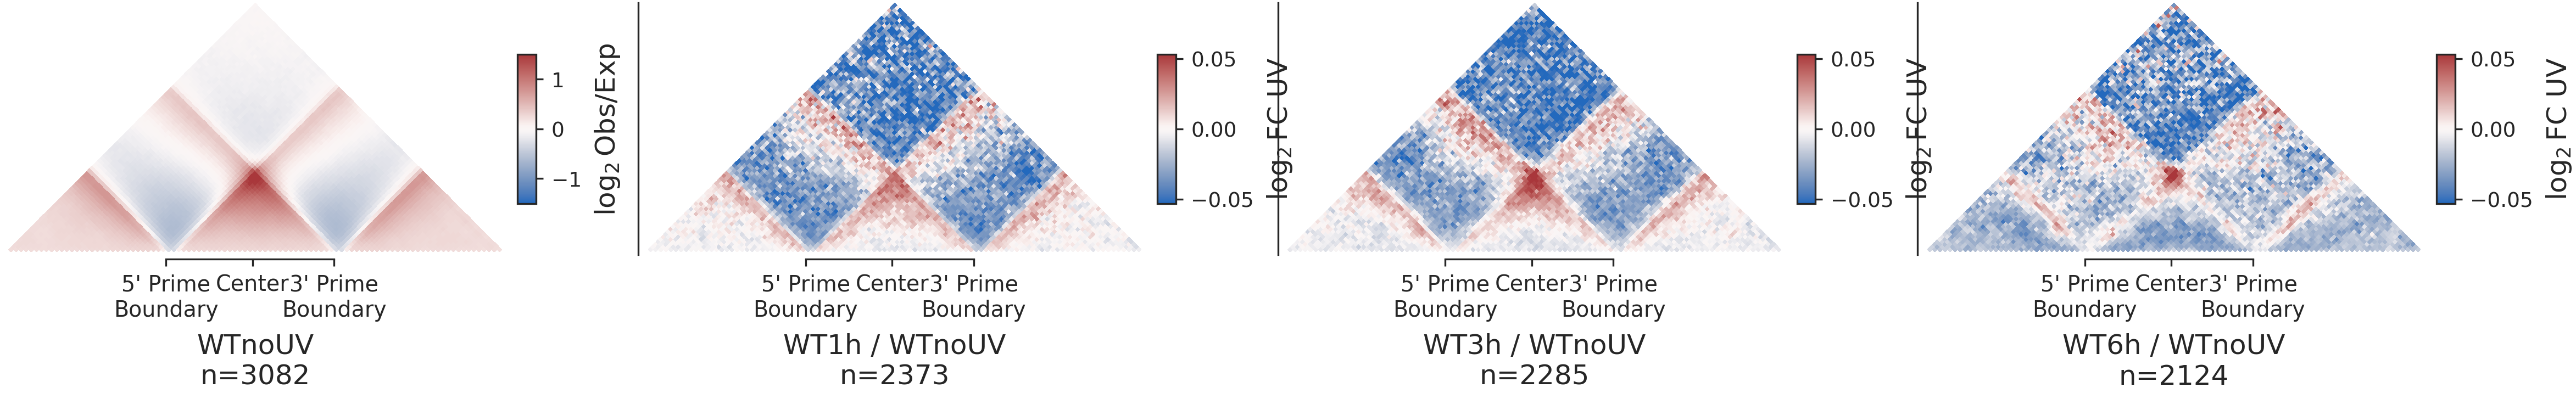

In [15]:
# WT UV vs noUV TAD pileups as log2 fold-change (L2FC)
# base panel = Obs/Exp, comparison panels = log2(UV / noUV)

eps = 1e-6

all_l2fc = []
for i in range(3):
    m_uv = wt_uv_pup[i]['data'][0]
    m_nouv = wt_nouv_pup[i]['data'][0]
    l2fc_mtx = np.log2((m_uv + eps) / (m_nouv + eps))
    all_l2fc.append(l2fc_mtx)

# diff_vmax = np.nanpercentile(all_l2fc, 99.9)
# diff_vmin = -diff_vmax

diff_vmin, diff_vmax = -0.25, 0.25

aspect_ratio = 4.8
fig, axs = plt.subplots(1, 4, figsize=(4 * aspect_ratio, 1 * aspect_ratio))
plotting.update_rcparams()

ax = plotting.hic_upper_triangle(
    np.log2(wt_pup['WTnoUV']['data'][0]),
    cmap="vlag",
    center=0,
    ax=axs[0],
    colorbar=True,
    vmin=-1.5, vmax=1.5,
    cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
)

n = wt_pup['WTnoUV']['data'][0].shape[0]
n_bins_rescaled = 99
fiveprime_bin = int(n_bins_rescaled * 0.33)
threeprime_bin = int(n_bins_rescaled * 0.66)
center_bin = int(n_bins_rescaled * 0.5)
bins = np.array([fiveprime_bin, center_bin, threeprime_bin])

ax.axis("on")
ax.set_xticks(2 * bins)
ax.set_xticks(
2 * bins,
labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
)
ax.set_xlabel(f"WTnoUV\nn={wt_pup['WTnoUV'].n[0]}", labelpad=5)
ax.tick_params(axis='x', labelsize=9.5)
ax.set_yticks([])

cbar = ax.figure.axes[-1]
cbar.set_ylabel(r"$\log_{2}$Obs/Exp", labelpad=5)

plotting.despine(ax)

tads_lens = [len(tads) for tads in preserved_tads]
for i, comp in enumerate(comps):
    i1, i2 = comp
    s1, s2 = list(wt_pup.keys())[i1], list(wt_pup.keys())[i2]
    l2fc_mtx_comp = all_l2fc[i]

    ax = plotting.hic_upper_triangle(
        l2fc_mtx_comp,
        cmap="vlag",
        center=0,
        vmin=diff_vmin,
        vmax=diff_vmax,
        ax=axs[i + 1],
        colorbar=True,
        cbar_kws=dict(fraction=0.035, pad=0.02, aspect=8)
    )

    n = l2fc_mtx_comp.shape[0]
    bins = np.array([int(n * 0.33), int(n * 0.5), int(n * 0.66)])

    ax.axis("on")
    ax.set_xticks(2 * bins)
    ax.set_xticks(
    2 * bins,
    labels=["5' Prime\nBoundary", "Center", "3' Prime\nBoundary"]
    )
    ax.set_xlabel(f"{s2} / {s1}\nn={tads_lens[i]}", labelpad=5)
    ax.tick_params(axis='x', labelsize=9.5)
    
    ax.set_yticks([])
    ax.get_yaxis().set_visible(False)

    cbar = ax.figure.axes[-1]
    cbar.set_ylabel(r"$\log_{2}$FC UV", labelpad=5)

    plotting.despine(ax)

fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig1/tad_pileups_wtnouv_tads_and_l2fc_preserved.svg',
    bbox_inches='tight'
)

### e1 on tads

In [16]:
chrom_blacklist = ['chr6', 'chr21', 'chr22']
# tads_df = tads_df.loc[~tads_df['chrom'].isin(chrom_blacklist)]

current_tads_df = preserved_tads[1] # wtnouv vs wt3h preserved tads
current_tads_df = current_tads_df.loc[~current_tads_df['chrom'].isin(chrom_blacklist)]

wt_tads_nouv = assign_domain_score(
    tads_df=current_tads_df,
    clr=clr_['WTnoUV'],
    expected=get_expected_cis_df('WTnoUV', label='chrom', resolution_kb=10),
    view_df=prepare_view_df(arm=False),
    resolution=10_000,
    nproc=6,
    clr_weight_name='sweight',
    rescale_flank=rescale_flank,
    rescale_size=rescale_size,
    score_flank=score_flank
)

wt_tads_3h = assign_domain_score(
    tads_df=current_tads_df,
    clr=clr_['WT3h'],
    expected=get_expected_cis_df('WT3h', label='chrom', resolution_kb=10),
    view_df=prepare_view_df(arm=False),
    resolution=10_000,
    nproc=6,
    clr_weight_name='sweight',
    rescale_flank=rescale_flank,
    rescale_size=rescale_size,
    score_flank=score_flank
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7', 'chr7'): 121
INFO:coolpuppy:('chr5', 'chr5'): 141
INFO:coolpuppy:('chr4', 'chr4'): 143
INFO:coolpuppy:('chr3', 'chr3'): 150
INFO:coolpuppy:('chr1', 'chr1'): 202
INFO:coolpuppy:('chr2', 'chr2'): 175
INFO:coolpuppy:('chr9', 'chr9'): 99
INFO:coolpuppy:('chr8', 'chr8'): 111
INFO:coolpuppy:('chr10', 'chr10'): 102
INFO:coolpuppy:('chr13', 'chr13'): 67
INFO:coolpuppy:('chr11', 'chr11'): 122
INFO:coolpuppy:('chr12', 'chr12'): 114
INFO:coolpuppy:('chr14', 'chr14'): 82
INFO:coolpuppy:('chr15', 'chr15'): 67
INFO:coolpuppy:('chr16', 'chr16'): 53
INFO:coolpuppy:('chr17', 'chr17'): 67
INFO:coolpuppy:('chr18', 'chr18'): 56
INFO:coolpuppy:('chr19', 'chr19'): 55
INFO:coolpuppy:('chr20', 'chr20'): 56
INFO:coolpuppy:('chrX', 'chrX'): 98
INFO:coolpuppy:Total number of piled up windows: 202
INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7', 'chr7'): 121
INFO:coolpuppy:('chr5', 'chr5'

In [17]:
wt_tads = wt_tads_nouv[['chrom', 'start', 'end']].copy()
wt_tads['WTnoUV_domain_score'] = wt_tads_nouv['domain_score']
wt_tads['WT3h_domain_score'] = wt_tads_3h['domain_score']
wt_tads['delta_domain_score'] = wt_tads['WT3h_domain_score'] - wt_tads['WTnoUV_domain_score']

In [18]:
_, wtnouv_ev_vector = get_eig_data('WTnoUV', resolution=100_000)
wtnouv_ev_vector = wtnouv_ev_vector.loc[~wtnouv_ev_vector['chrom'].isin(chrom_blacklist)][['chrom', 'start', 'end', 'E1']]

In [19]:
from ggner_3d.boundaries import assign_e1_to_tad_bins

_, tads_with_e1 = assign_e1_to_tad_bins(
    ev=wtnouv_ev_vector,
    tads=wt_tads,
    ev_res=100_000,
    bin_res=10_000,
    agg=np.nanmedian
)

tads_with_e1['compartment'] = tads_with_e1['E1_agg'].apply(lambda x: 'A' if x > 0 else 'B')

/home/carlos/Clone/ggner-3d/src/ggner_3d/boundaries.py:440: RuntimeWarning: invalid value encountered in divide
  bins_df[f"{value_col}_bin"] = np.where(den > 0, num / den, np.nan)


In [20]:
tads_with_e1.columns

Index(['chrom', 'start', 'end', 'WTnoUV_domain_score', 'WT3h_domain_score',
       'delta_domain_score', 'tad_id', 'E1_agg', 'compartment'],
      dtype='object')

In [21]:
delta_min, delta_max = np.nanpercentile(tads_with_e1['delta_domain_score'], [0.1, 99.9])
tads_with_e1 = tads_with_e1.loc[
    (tads_with_e1['delta_domain_score'] >= delta_min) &
    (tads_with_e1['delta_domain_score'] <= delta_max)
]

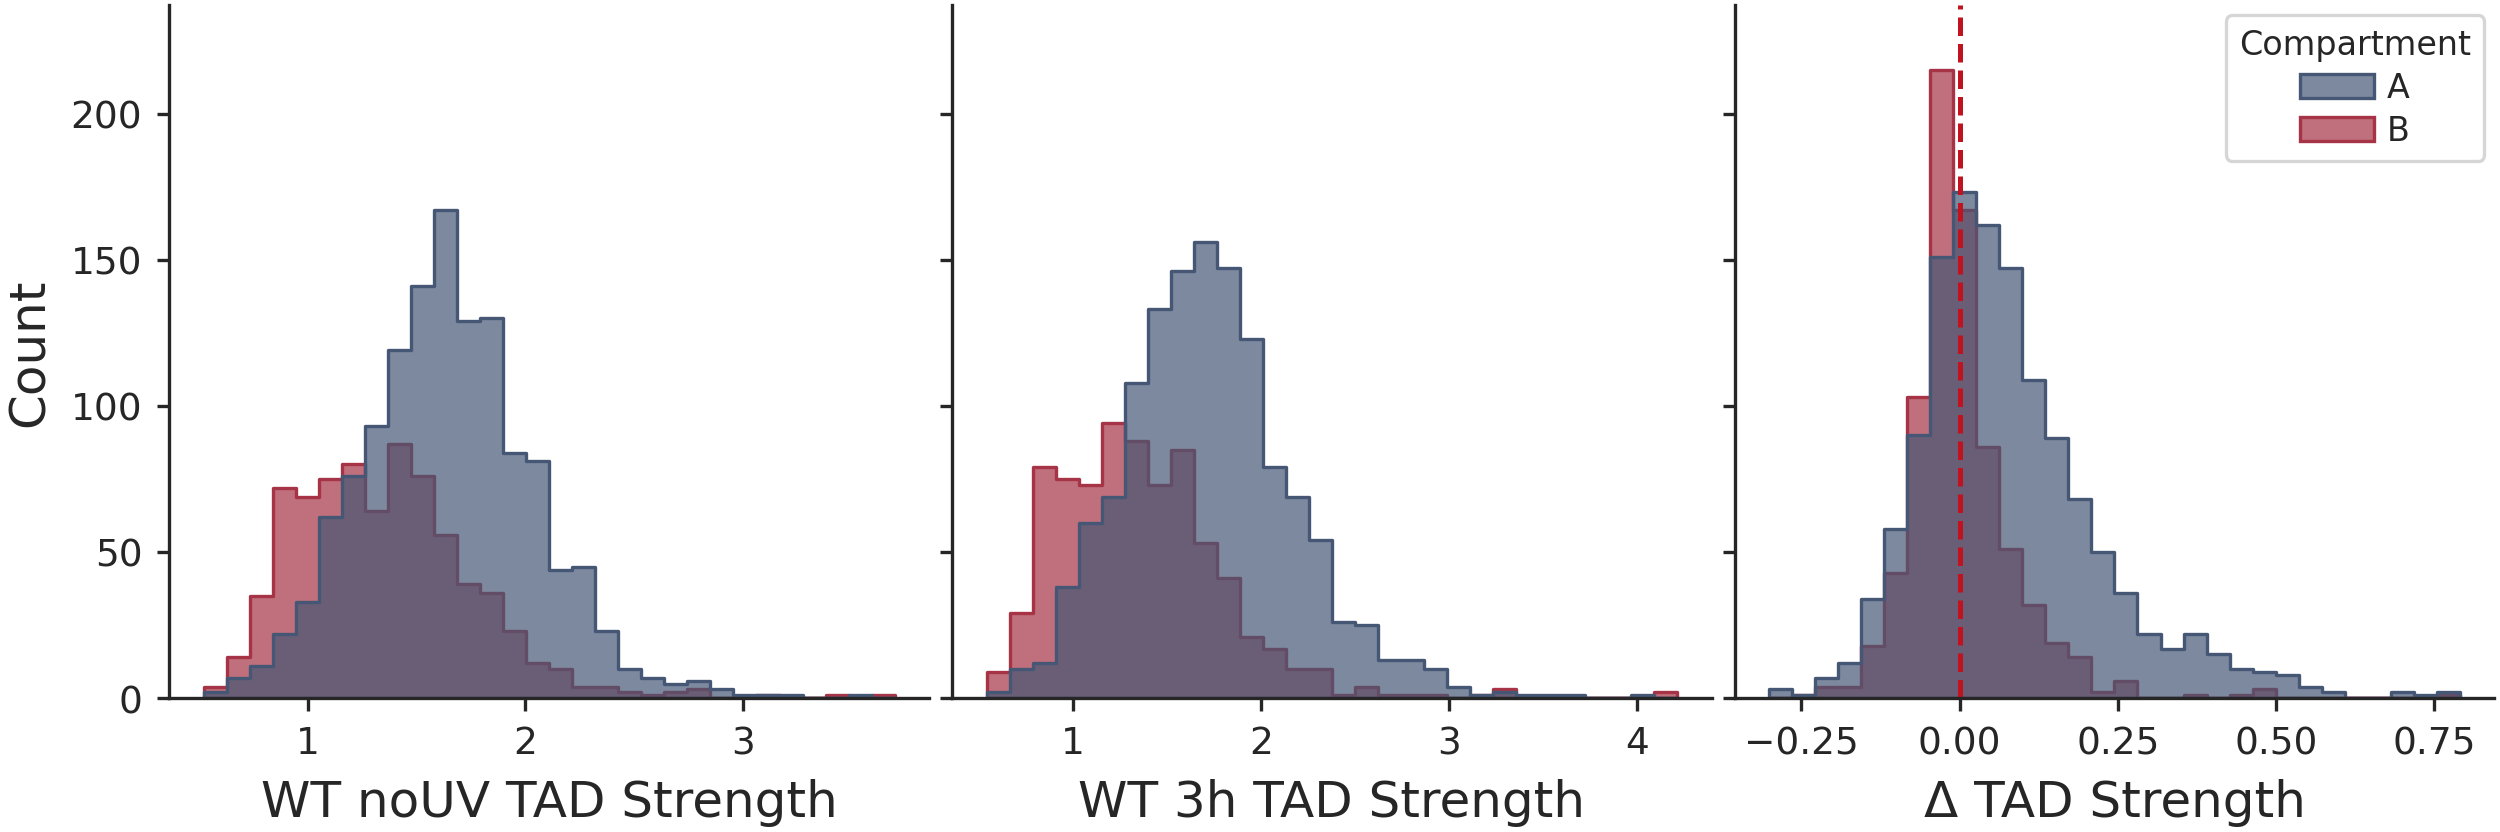

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# viz
nbins = 30
fig, axs = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
fig.subplots_adjust(wspace=0.03)

# ensure consistent hue order
tads_with_e1["compartment"] = pd.Categorical(
    tads_with_e1["compartment"],
    categories=["A", "B"],
    ordered=True,
)

# --- panel 1 ---
sns.histplot(
    data=tads_with_e1,
    x="WTnoUV_domain_score",
    hue="compartment",
    bins=nbins,
    element="step",
    stat="count",
    common_norm=False,
    palette={"A": plotting.COLORS[0], "B": plotting.COLORS[1]},
    alpha=0.7,
    ax=axs[0],
)

# --- panel 2 ---
sns.histplot(
    data=tads_with_e1,
    x="WT3h_domain_score",
    hue="compartment",
    bins=nbins,
    element="step",
    stat="count",
    common_norm=False,
    palette={"A": plotting.COLORS[0], "B": plotting.COLORS[1]},
    alpha=0.7,
    ax=axs[1],
)

# --- panel 3 ---
sns.histplot(
    data=tads_with_e1,
    x="delta_domain_score",
    hue="compartment",
    bins=nbins,
    element="step",
    stat="count",
    common_norm=False,
    palette={"A": plotting.COLORS[0], "B": plotting.COLORS[1]},
    alpha=0.7,
    ax=axs[2],
    legend=True,
)

# -----------------------
# FIX shared-y "clipping":
# compute the max bar height across all axes and set ylim on the *first* axis.
# Because sharey=True, this propagates to all.
# -----------------------
def ax_max_height(ax):
    if ax.patches:
        return max(p.get_height() for p in ax.patches)
    return ax.get_ylim()[1]

ymax = max(ax_max_height(ax) for ax in axs)
axs[0].set_ylim(0, ymax * 1.05)

# cosmetics / consistent despine
for ax in axs:
    sns.despine(ax=ax)  # more consistent than some custom despine
    ax.grid(False)

# legends: keep only the last
if axs[0].legend_ is not None:
    axs[0].legend_.remove()
if axs[1].legend_ is not None:
    axs[1].legend_.remove()
if axs[2].legend_ is not None:
    axs[2].legend_.set_title("Compartment")

# labels
axs[0].set_xlabel("WT noUV TAD Strength")
axs[1].set_xlabel("WT 3h TAD Strength")
axs[2].set_xlabel("Δ TAD Strength")

# optional: avoid repeating y-label on all panels
axs[1].set_ylabel("")
axs[2].set_ylabel("")

# vertical reference line for delta panel
axs[2].axvline(0, color="#c1121f", linestyle="--")

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig1/tad_strengths_by_compartment_wtnouv_e1.svg")
plt.show()


### all samples tad strength comparison

In [ ]:
wtnouv_tads_df = insulation_dfs['WTnoUV'].loc[
    insulation_dfs['WTnoUV'][f'is_boundary_{window_bp}'] == True,
    ['chrom', 'start', 'end']
]
wtnouv_tads_df = make_tads(
    wtnouv_tads_df,
    maxlen = MAXLEN,
    minlen = MINLEN)
print(wtnouv_tads_df.shape)

(3095, 3)


In [ ]:
tad_strengths = {}

use_wtnouv_tads = False

if use_wtnouv_tads:
    for sample in ['WTnoUV', 'WT1h', 'WT3h', 'WT6h', 'XPCnoUV', 'XPC3h', 'XPAnoUV', 'XPA1h', 'XPA3h', 'XPA6h']:
        tad_strengths[sample] = assign_domain_score(
            tads_df=wtnouv_tads_df,
            clr=clr_[sample],
            expected=get_expected_cis_df(sample, label='chrom', resolution_kb=10),
            view_df=prepare_view_df(arm=False),
            resolution=10_000,
            nproc=8,
            clr_weight_name='sweight',
            rescale_flank=rescale_flank,
            rescale_size=rescale_size,
            score_flank=score_flank
)
else:
    for sample in ['WTnoUV', 'WT1h', 'WT3h', 'WT6h', 'XPCnoUV', 'XPC3h', 'XPAnoUV', 'XPA1h', 'XPA3h', 'XPA6h']:
        current_tads = make_tads(
            insulation_dfs[sample].loc[
                insulation_dfs[sample][f'is_boundary_{window_bp}'] == True,
                ['chrom', 'start', 'end']
            ],
            maxlen = MAXLEN,
            minlen = MINLEN
        )
        tad_strengths[sample] = assign_domain_score(
            tads_df=current_tads,
            clr=clr_[sample],
            expected=get_expected_cis_df(sample, label='chrom', resolution_kb=10),
            view_df=prepare_view_df(arm=False),
            resolution=10_000,
            nproc=8,
            clr_weight_name='sweight',
            rescale_flank=rescale_flank,
            rescale_size=rescale_size,
            score_flank=score_flank
)

INFO:coolpuppy:Rescaling with rescale_flank = 1 to 99x99 pixels
INFO:coolpuppy:('chr7', 'chr7'): 156
INFO:coolpuppy:('chr8', 'chr8'): 156
INFO:coolpuppy:('chr6', 'chr6'): 192
INFO:coolpuppy:('chr5', 'chr5'): 186
INFO:coolpuppy:('chr4', 'chr4'): 199
INFO:coolpuppy:('chr3', 'chr3'): 215
INFO:coolpuppy:('chr1', 'chr1'): 266
INFO:coolpuppy:('chr2', 'chr2'): 244
INFO:coolpuppy:('chr9', 'chr9'): 126
INFO:coolpuppy:('chr14', 'chr14'): 106
INFO:coolpuppy:('chr13', 'chr13'): 96
INFO:coolpuppy:('chr15', 'chr15'): 98
INFO:coolpuppy:('chr11', 'chr11'): 161
INFO:coolpuppy:('chr10', 'chr10'): 134
INFO:coolpuppy:('chr12', 'chr12'): 161
INFO:coolpuppy:('chr21', 'chr21'): 29
INFO:coolpuppy:('chr19', 'chr19'): 65
INFO:coolpuppy:('chr17', 'chr17'): 89
INFO:coolpuppy:('chr16', 'chr16'): 75
INFO:coolpuppy:('chr22', 'chr22'): 39
INFO:coolpuppy:('chr20', 'chr20'): 74
INFO:coolpuppy:('chr18', 'chr18'): 76
INFO:coolpuppy:('chrX', 'chrX'): 139
INFO:coolpuppy:Total number of piled up windows: 266
INFO:coolpuppy:

In [ ]:
import numpy as np
import pandas as pd

plot_df = {
    'sample': [],
    'domain_score': []
}

for k, v in tad_strengths.items():
    v = v.copy()
    v['domain_score'] = pd.to_numeric(v['domain_score'], errors='coerce')
    v = v[np.isfinite(v['domain_score'])]

    print(f'{k}: {v["domain_score"].mean():.4f} ± {v["domain_score"].std():.4f}')
    plot_df['sample'].extend([sample_name_formatter(k)] * v.shape[0])
    plot_df['domain_score'].extend(v['domain_score'].to_list())

plot_df = pd.DataFrame(plot_df)

WTnoUV: 1.5400 ± 0.4226
WT1h: 1.5822 ± 0.4729
WT3h: 1.5903 ± 0.4933
WT6h: 1.5392 ± 0.4627
XPCnoUV: 1.6317 ± 0.4887
XPC3h: 1.6755 ± 0.5430
XPAnoUV: 1.5127 ± 0.4189
XPA1h: 1.5148 ± 0.4282
XPA3h: 1.5304 ± 0.4563
XPA6h: 1.3692 ± 0.3616


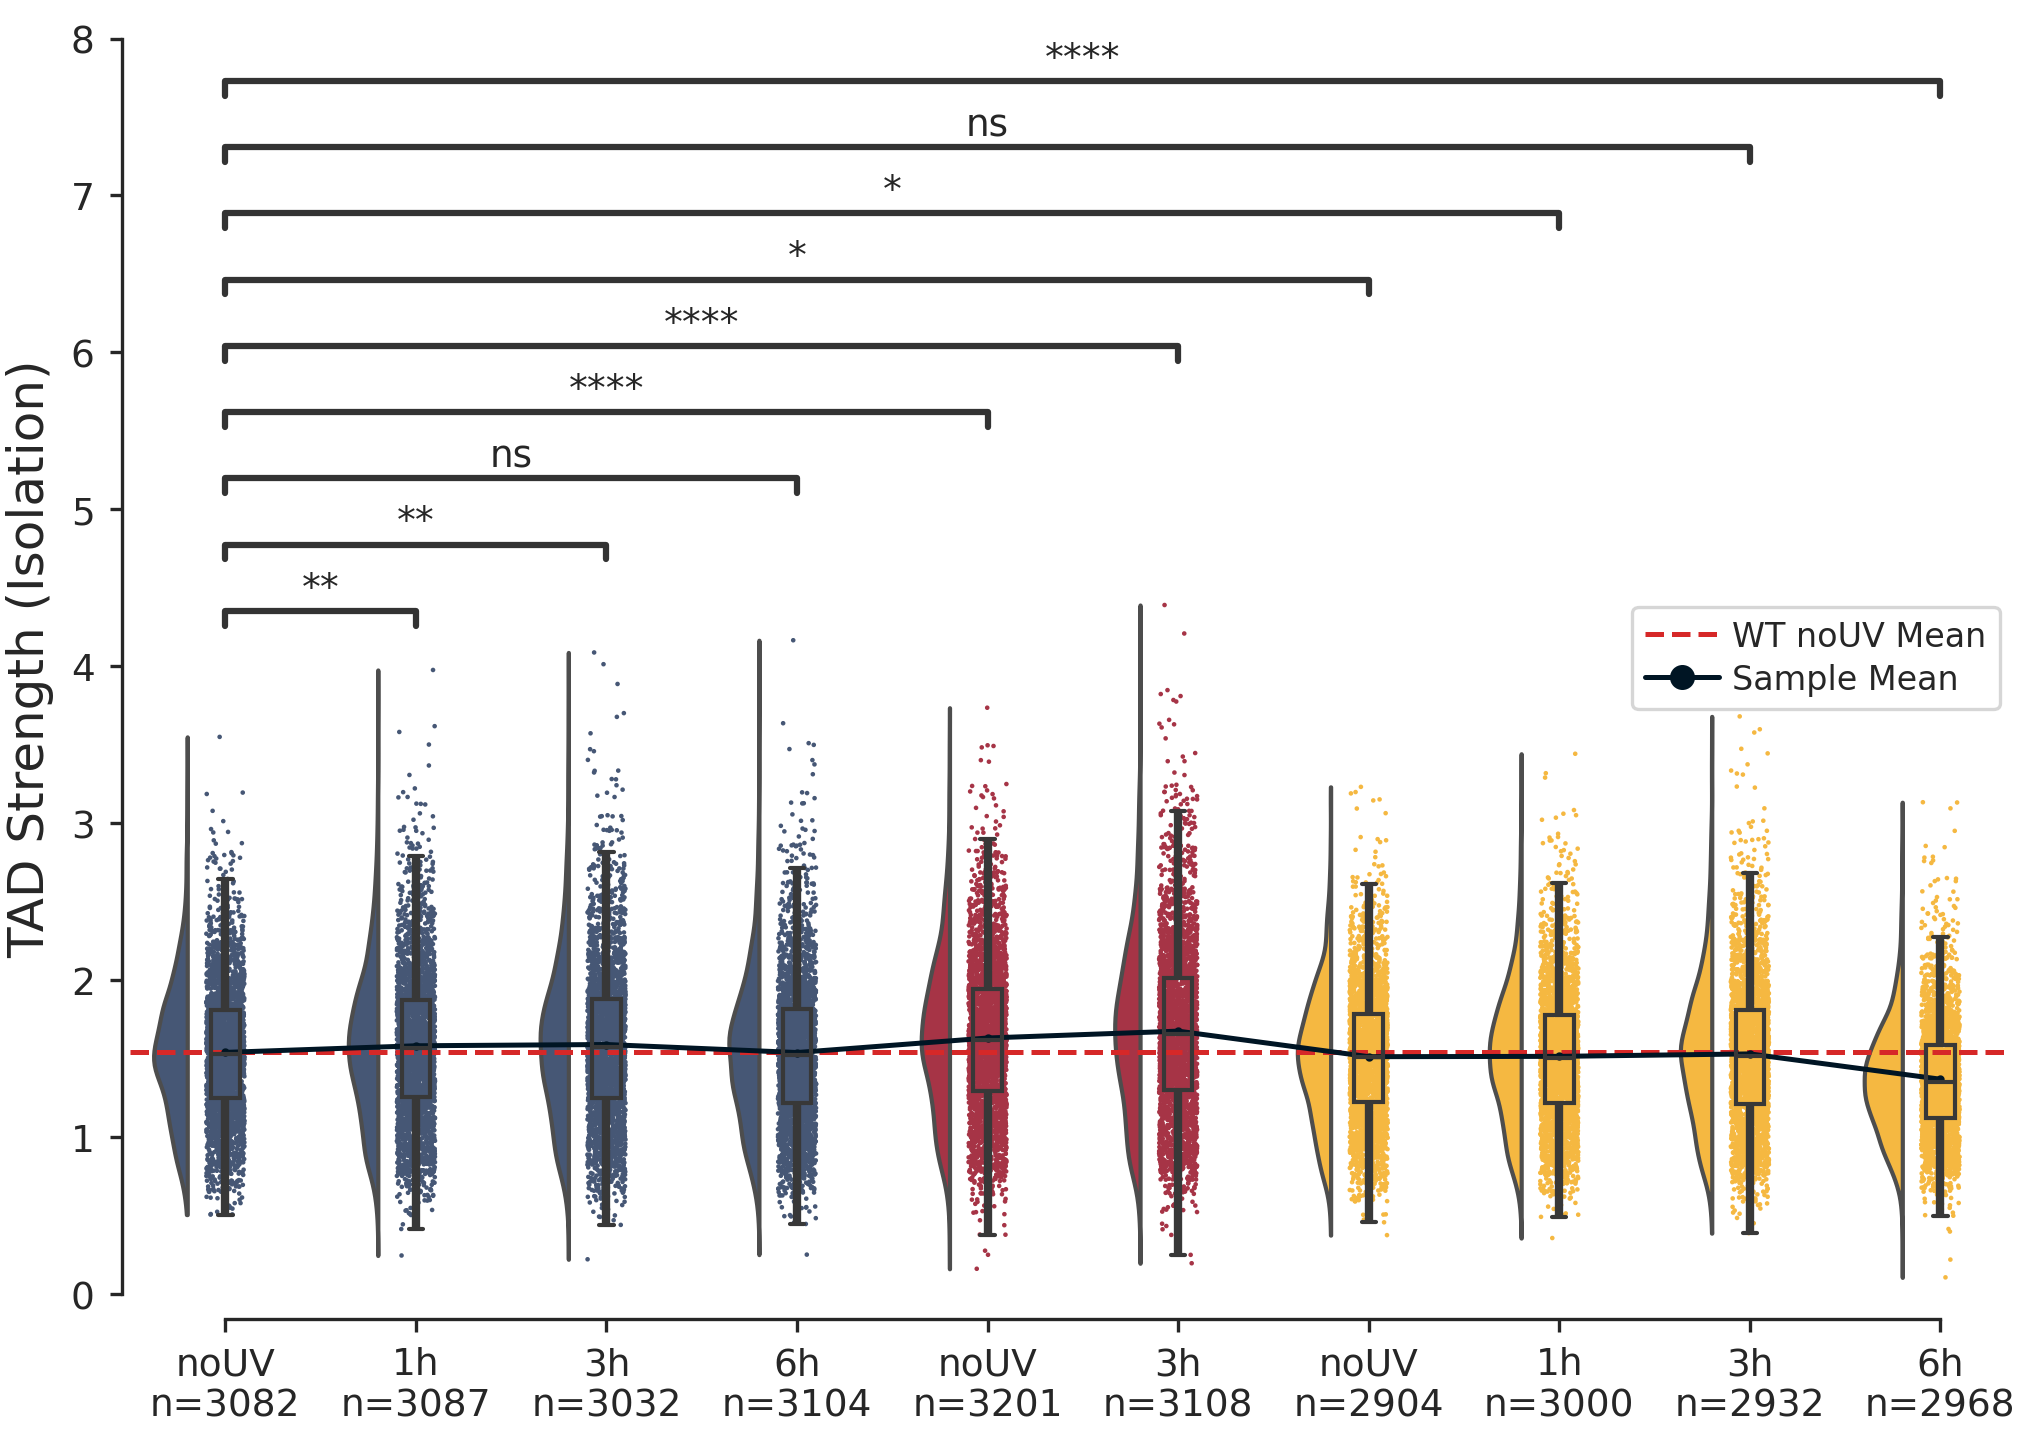

In [26]:
# -----------------------
# plot config
# -----------------------
ort = 'v'
# pal = plotting.COLORS
pal = [plotting.COLORS[0]] * 4 + [plotting.COLORS[1]] * 2 + [plotting.COLORS[2]] * 4
dx = 'sample'
dy = 'domain_score'
sigma = 0.2

# IMPORTANT: define a stable category order for both RainCloud + statannotations
order = [sample_name_formatter(s) for s in samples_oi]  # -> ['WT noUV','WT 1h','WT 3h','WT 6h']

# -----------------------
# raincloud plot
# -----------------------
fig, ax = plt.subplots(figsize=(7, 5))

# NOTE: Don't set hue="sample" when x="sample" (redundant and can confuse annotation pairing).
ax = pt.RainCloud(
    x=dx,
    y=dy,
    data=plot_df,
    order=order,
    palette=pal,
    bw=sigma,
    width_viol=0.4,
    ax=ax,
    orient=ort,
    move=0.0,
    # pointplot=True,
    box_showfliers=False,
    point_size=1.1,
    linecolor="#001524"
)



ax.set_ylabel('TAD Strength (Isolation)')
# add n boundaries to x tick labels
xticks = []
for sample in order:
    n_points = plot_df.loc[plot_df['sample'] == sample, 'domain_score'].shape[0]
    xticks.append(f'{sample.replace("WT", "WT ").replace("XPA", "XPA ").replace("XPC", "XPC ").split()[1]}\nn={n_points}')
ax.set_xticklabels(xticks)
ax.set_xlabel('')

# WT mean line
wt_label = sample_name_formatter('WTnoUV')  # "WT noUV"
wt_mean = plot_df.loc[plot_df['sample'] == wt_label, 'domain_score'].mean()
ax.axhline(wt_mean, color='#d62828', linestyle='--', label='WT noUV Mean')

# -----------------------
# statannotations: compare each group vs WT noUV
# -----------------------
pairs = [(order[0], g) for g in order[1:]]  # WT noUV vs each other sample

annot = Annotator(
    ax,
    pairs,
    data=plot_df,
    x=dx,
    y=dy,
    order=order,
)

annot.configure(
    test="Mann-Whitney",              # alternatives: "t-test_ind", "Wilcoxon", ...
    text_format="star",               # alternatives: "simple" (shows p=...)
    loc="inside",                    # keeps brackets above the plot
    verbose=0
)

annot.apply_and_annotate()

# add line connectors between means of each group
means = plot_df.groupby('sample')['domain_score'].mean().reindex(order)
ax.plot(range(len(order)), means, color='#001524', linestyle='-', marker='o', markersize=1)
# add to legend
ax.plot([], [], color='#001524', linestyle='-', marker='o', markersize=5, label='Sample Mean')

ax.legend()
plotting.despine(ax)
plt.tight_layout()

fig.savefig(
    '/home/carlos/Clone/ggner-3d/figs/fig1/domain_strength_500Kb_individual_tads_annot_annot.svg'
)